<a href="https://colab.research.google.com/github/Aryan123Yad/madeeasy/blob/main/insurancemlproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:


import pandas as pd

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

df = pd.read_csv(url)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

df = pd.read_csv(url)

df.to_csv("insurance.csv", index=False)

print("insurance.csv ready!")

insurance.csv ready!


In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())



Rows: 1338
Columns: 7

Columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [9]:
df.to_csv("insurance.csv", index=False)

print("insurance.csv created successfully!")

insurance.csv created successfully!


EDA

In [10]:
df.shape

(1338, 7)

In [11]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [13]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [14]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [15]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [16]:
numeric_columns = df.select_dtypes(include=['number']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Numeric Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numeric Columns:
Index(['age', 'bmi', 'children', 'charges'], dtype='object')

Categorical Columns:
Index(['sex', 'smoker', 'region'], dtype='object')


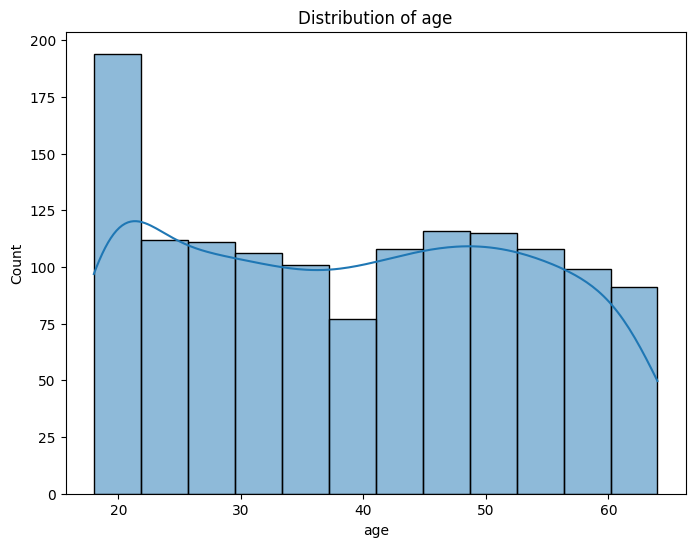

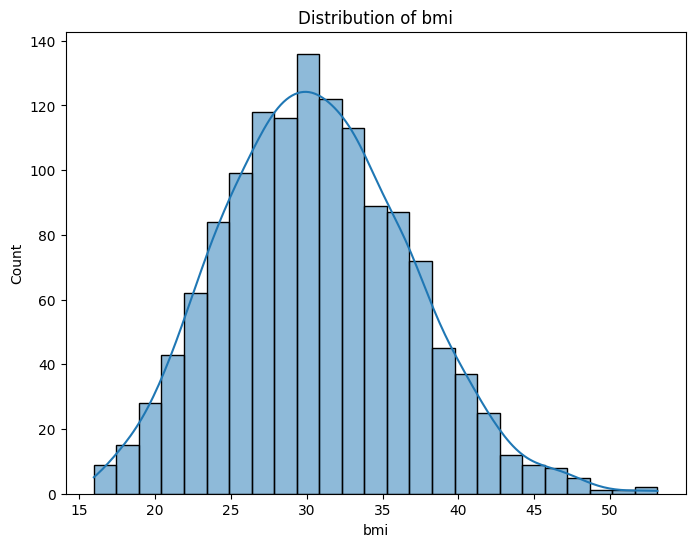

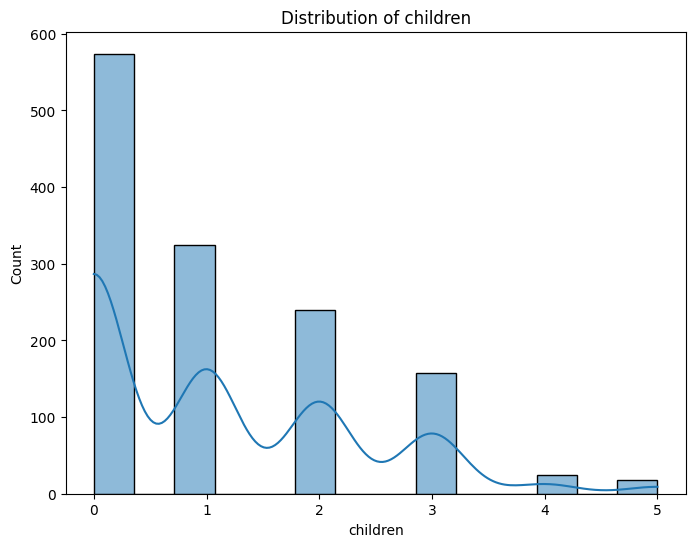

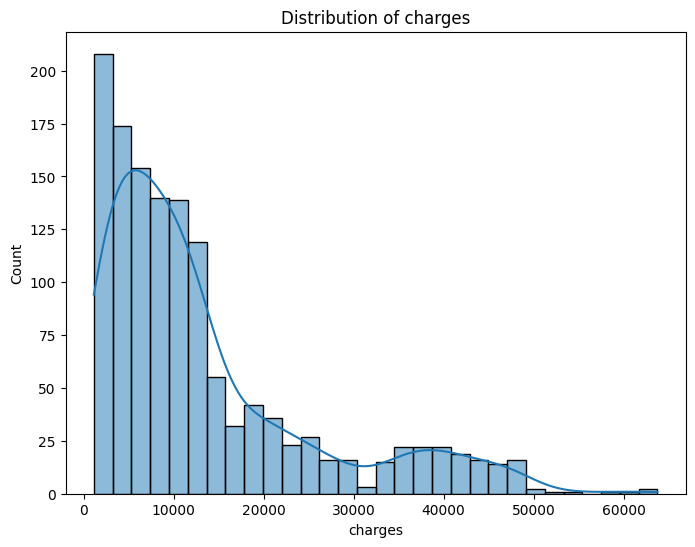

In [17]:
numeric_columns = ['age', 'bmi', 'children', 'charges']
for col in numeric_columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()



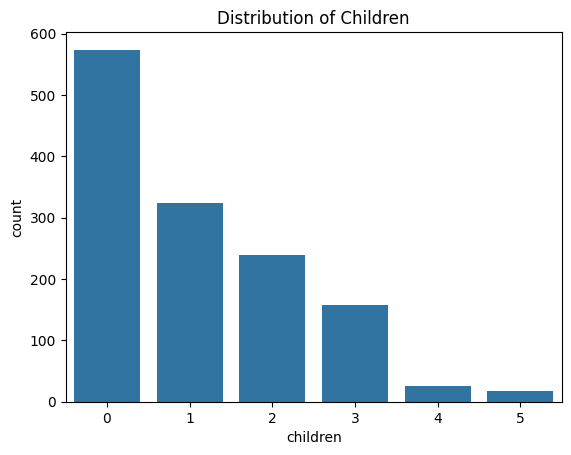

In [18]:
sns.countplot(data=df, x='children')
plt.title('Distribution of Children')
plt.show()




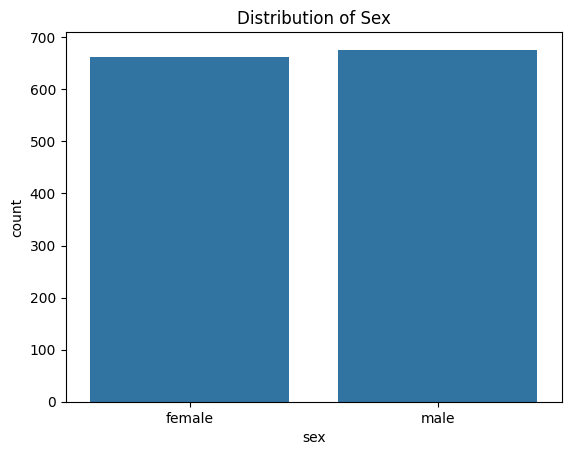

In [19]:
sns.countplot(data=df, x='sex')
plt.title('Distribution of Sex')
plt.show()

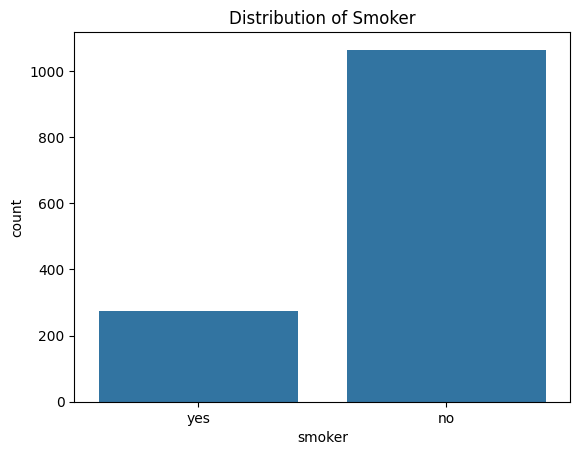

In [20]:
sns.countplot(data=df, x='smoker')
plt.title('Distribution of Smoker')
plt.show()

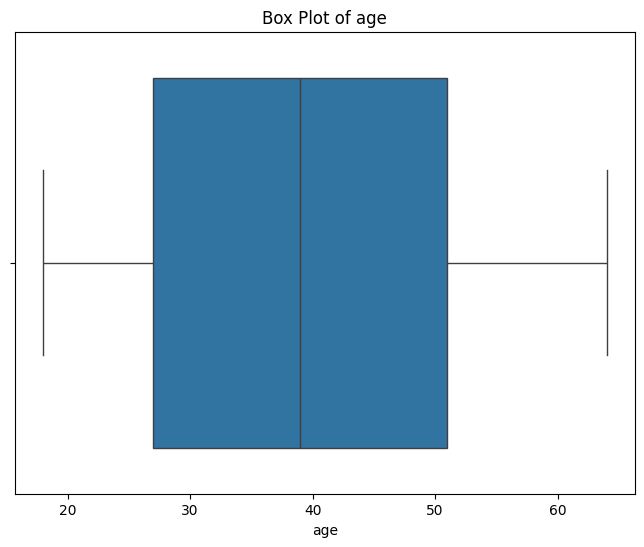

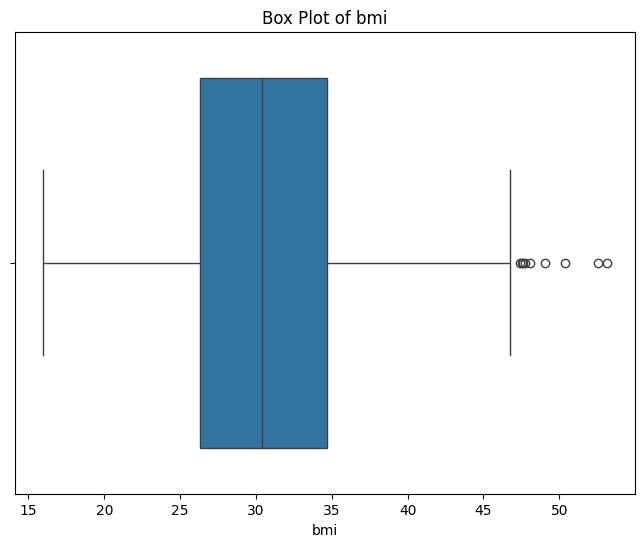

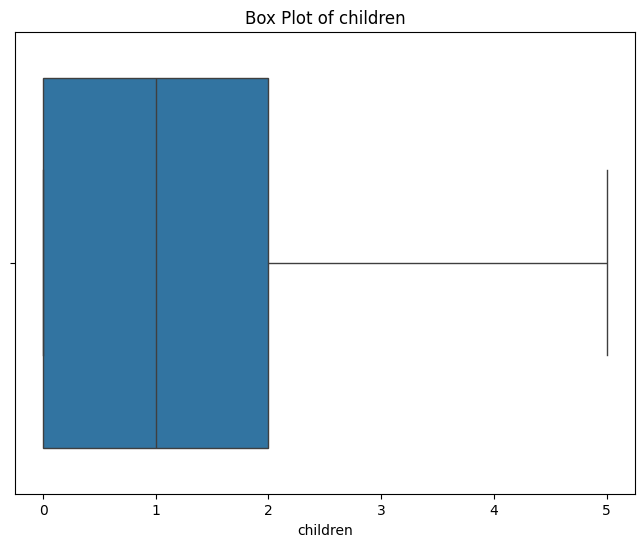

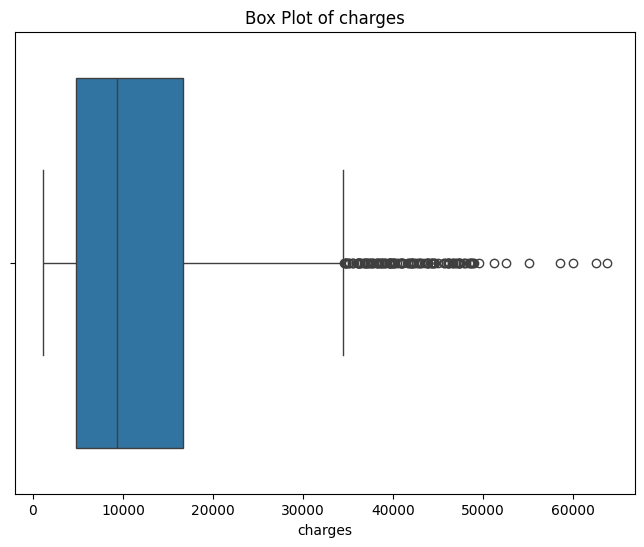

In [21]:
for col in numeric_columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x=col)
    plt.title(f'Box Plot of {col}')
    plt.show()




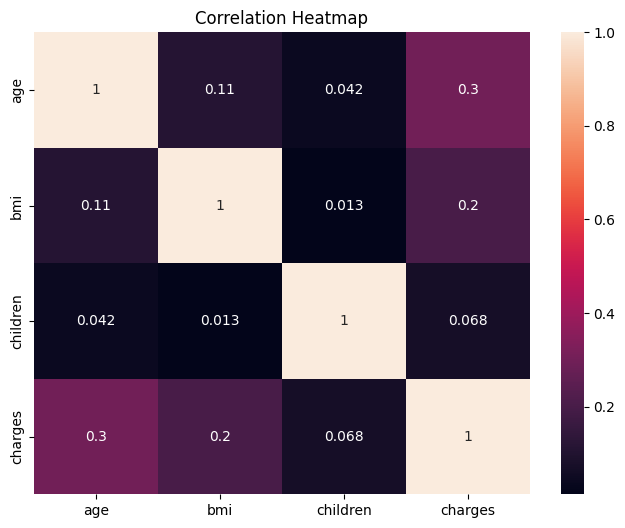

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True,)
plt.title('Correlation Heatmap')
plt.show()


DATA CLEANING AND PREPROCESSING

In [23]:
df_cleaned = df.copy()

In [24]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [25]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [26]:
df_cleaned.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [27]:
df_cleaned.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [28]:
df_cleaned.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [29]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [30]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [31]:
df_cleaned.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [32]:
df_cleaned.drop_duplicates(inplace =True)

In [33]:
df_cleaned.shape

(1337, 7)

In [34]:
df_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [35]:
df_cleaned['sex'] .value_counts()

,count
sex,
male,675
female,662


In [36]:
df_cleaned['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [37]:
df_cleaned['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [38]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [39]:
df_cleaned.rename(
    columns={
        'sex': 'gender',
       'smoker': 'is_smoker',

    }
  )

,age,gender,bmi,children,is_smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [40]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [41]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], drop_first=True)

In [42]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,female,27.900,0,yes,16884.92400,False,False,True
1,18,male,33.770,1,no,1725.55230,False,True,False
2,28,male,33.000,3,no,4449.46200,False,True,False
3,33,male,22.705,0,no,21984.47061,True,False,False
4,32,male,28.880,0,no,3866.85520,True,False,False


FEATURE ENGINEERING AND EXTRACTION

<Axes: xlabel='bmi', ylabel='Count'>

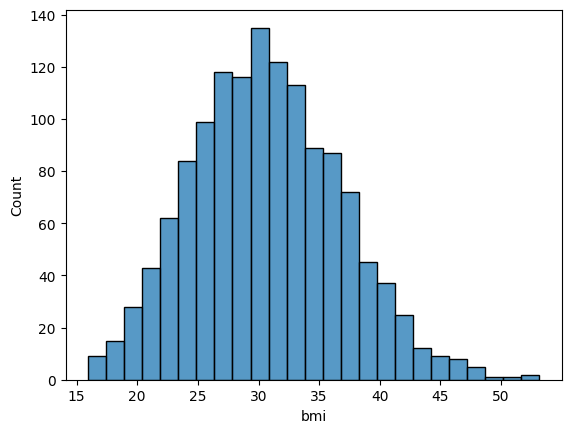

In [43]:
import seaborn as sns
sns.histplot(df_cleaned['bmi'])

In [44]:
df_cleaned['bmi_category'] = pd.cut(df_cleaned['bmi'], bins=[0, 18.5, 24.9, 29.9, float('inf')],
                                   labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

In [45]:
df_cleaned

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,female,27.900,0,yes,16884.92400,False,False,True,Overweight
1,18,male,33.770,1,no,1725.55230,False,True,False,Obese
2,28,male,33.000,3,no,4449.46200,False,True,False,Obese
3,33,male,22.705,0,no,21984.47061,True,False,False,Normal
4,32,male,28.880,0,no,3866.85520,True,False,False,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830,True,False,False,Obese
1334,18,female,31.920,0,no,2205.98080,False,False,False,Obese
1335,18,female,36.850,0,no,1629.83350,False,True,False,Obese
1336,21,female,25.800,0,no,2007.94500,False,False,True,Overweight


In [46]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,female,27.900,0,yes,16884.92400,False,False,True,Overweight
1,18,male,33.770,1,no,1725.55230,False,True,False,Obese
2,28,male,33.000,3,no,4449.46200,False,True,False,Obese
3,33,male,22.705,0,no,21984.47061,True,False,False,Normal
4,32,male,28.880,0,no,3866.85520,True,False,False,Overweight


In [47]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'], drop_first=True)

In [52]:
df_cleaned['sex'] = df_cleaned['sex'].map({
    'male': 0,
    'female': 1
})

df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27.900,0,yes,16884.92400,False,False,True,False,True,False
1,18,0,33.770,1,no,1725.55230,False,True,False,False,False,True
2,28,0,33.000,3,no,4449.46200,False,True,False,False,False,True
3,33,0,22.705,0,no,21984.47061,True,False,False,True,False,False
4,32,0,28.880,0,no,3866.85520,True,False,False,False,True,False


In [54]:
# Categorical columns ko numbers me convert karo
df_cleaned = pd.get_dummies(df_cleaned, drop_first=True, dtype=int)

# Ab numeric data ko int me convert karo
df_cleaned = df_cleaned.astype(int)

# Check karo
df_cleaned.head()

,age,sex,bmi,children,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,smoker_yes
0,19,1,27,0,16884,0,0,1,0,1,0,1
1,18,0,33,1,1725,0,1,0,0,0,1,0
2,28,0,33,3,4449,0,1,0,0,0,1,0
3,33,0,22,0,21984,1,0,0,1,0,0,0
4,32,0,28,0,3866,1,0,0,0,1,0,0


In [62]:
df_cleaned = df_cleaned.astype(int)

In [58]:
df_cleaned.head()

,age,sex,bmi,children,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,smoker_yes
0,19,1,27,0,16884,0,0,1,0,1,0,1
1,18,0,33,1,1725,0,1,0,0,0,1,0
2,28,0,33,3,4449,0,1,0,0,0,1,0
3,33,0,22,0,21984,1,0,0,1,0,0,0
4,32,0,28,0,3866,1,0,0,0,1,0,0


In [59]:
df_cleaned.columns

Index(['age', 'sex', 'bmi', 'children', 'charges', 'region_northwest',
       'region_southeast', 'region_southwest', 'bmi_category_Normal',
       'bmi_category_Overweight', 'bmi_category_Obese', 'smoker_yes'],
      dtype='object')

In [60]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()

df_cleaned[cols] = StandardScaler().fit_transform(df_cleaned[cols])

In [61]:
df_cleaned.head()

,age,sex,bmi,children,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,smoker_yes
0,-1.440418,1,-0.517949,-0.909234,16884,0,0,1,0,1,0,1
1,-1.511647,0,0.462463,-0.079442,1725,0,1,0,0,0,1,0
2,-0.799350,0,0.462463,1.580143,4449,0,1,0,0,0,1,0
3,-0.443201,0,-1.334960,-0.909234,21984,1,0,0,1,0,0,0
4,-0.514431,0,-0.354547,-0.909234,3866,1,0,0,0,1,0,0
